In [19]:
import re

def extract_par_utterances(filepath):
    utterances = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('*PAR:'):
                try:
                    _, utterance = line.split(':', 1)
                    utterances.append(utterance.strip())
                except ValueError:
                    continue
    return utterances

def extract_utterance_with_times(utt):
    match = re.search(r'\x15(\d+)_(\d+)\x15', utt)
    if not match:
        return
    start_time = int(match.group(1))
    end_time = int(match.group(2))
    utt = re.sub(r'\x15\d+_\d+\x15', '', utt).strip()
    return {"utterance": utt, "start_time": start_time, "end_time": end_time}

In [20]:
import os
import pandas as pd

BASE_DIR = "."

def load_metadata(path):
    df = pd.read_csv(path, delimiter=';')
    df.columns = df.columns.str.strip()
    df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
    if df.index.dtype == 'object':
        df.index = df.index.str.strip()
    return df

def load_sessions(directory):
    sessions = []
    for file in os.listdir(directory):
        if '.cha' not in file:
            continue
        session = [u for u in (extract_utterance_with_times(r) for r in extract_par_utterances(os.path.join(directory, file))) if u]
        sessions.append((file, session))
    return sessions

train_cd_meta = load_metadata(f"{BASE_DIR}/train/cd_meta_data.csv")
train_cc_meta = load_metadata(f"{BASE_DIR}/train/cc_meta_data.csv")

train_data, train_labels, train_mmse = [], [], []

def get_mmse(meta_df, file_id, default=None):
    file_id = os.path.splitext(file_id)[0]
    matches = meta_df[meta_df['ID'] == file_id]['mmse'].to_numpy()
    if len(matches) == 0:
        print(f"Warning: No metadata found for ID '{file_id}', using default={default}")
        return default
    return matches[0]

for file, session in load_sessions(f"{BASE_DIR}/train/transcription/cd"):
    train_data.append(session)
    train_labels.append(1)
    train_mmse.append(get_mmse(train_cd_meta, file, default=None))

for file, session in load_sessions(f"{BASE_DIR}/train/transcription/cc"):
    train_data.append(session)
    train_labels.append(0)
    val = get_mmse(train_cc_meta, file, default='NA')
    train_mmse.append(-1 if val == 'NA' else int(val))

test_data = [session for _, session in load_sessions(f"{BASE_DIR}/test/transcription")]

train_mmse

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1]

In [21]:
import numpy as np
import pandas as pd
import re
from typing import List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ── Temporal features ─────────────────────────────────────────────────────
# Each utterance dict has start_time and end_time (ms). We derive 5 features:
#  1. utterance_duration_s  - how long the utterance lasted (seconds)
#  2. pause_before_s        - silence gap before this utterance
#  3. speech_rate           - words per second (slow speech = AD marker)
#  4. relative_onset        - start_time / session_duration (0-1 position)
#  5. log_duration          - log1p(duration) to compress outliers
TEMPORAL_DIM = 5

def extract_temporal_features(session):
    """
    Compute temporal features for a list of utterance dicts.
    session is the FILTERED list (same utterances used for word vectors),
    so indices always align with word_means.
    """
    feats = []
    session_end = session[-1]['end_time'] if session else 1
    prev_end = session[0]['start_time'] if session else 0
    for utt in session:
        t0, t1 = utt['start_time'], utt['end_time']
        duration  = max(t1 - t0, 1)
        pause     = max(t0 - prev_end, 0)
        n_words   = max(len(utt['utterance'].split()), 1)
        rate      = n_words / (duration / 1000.0)
        rel_onset = t0 / max(session_end, 1)
        log_dur   = np.log1p(duration)
        feats.append([duration / 1000.0, pause / 1000.0, rate, rel_onset, log_dur])
        prev_end = t1
    arr = np.array(feats, dtype=np.float32)
    med = np.median(arr, axis=0)
    mad = np.median(np.abs(arr - med), axis=0) + 1e-6
    return np.clip((arr - med) / mad, -5, 5)


# ── Dataset ────────────────────────────────────────────────────────────────
# Simplified: each item is (word_means, time_feats, label)
# word_means shape: (num_utterances, embed_dim)  — mean-pooled word vectors
# time_feats shape: (num_utterances, TEMPORAL_DIM)
class AlzheimersDataset(Dataset):
    def __init__(self, sessions_word_mean, sessions_time, labels):
        self.sessions_word_mean = sessions_word_mean  # list of (S, E) arrays
        self.sessions_time = sessions_time            # list of (S, T) arrays
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.sessions_word_mean[idx]),
            torch.FloatTensor(self.sessions_time[idx]),
            torch.LongTensor([self.labels[idx]])
        )


def collate_fn(batch):
    word_seqs, time_seqs, labels = zip(*batch)
    sess_lengths = torch.LongTensor([w.shape[0] for w in word_seqs])
    max_len  = sess_lengths.max().item()
    embed_dim = word_seqs[0].shape[1]
    B = len(batch)
    word_tensor = torch.zeros(B, max_len, embed_dim)
    time_tensor = torch.zeros(B, max_len, TEMPORAL_DIM)
    for i, (w, t) in enumerate(zip(word_seqs, time_seqs)):
        n = w.shape[0]
        word_tensor[i, :n] = w
        time_tensor[i, :n] = t
    return word_tensor, time_tensor, sess_lengths, torch.cat(labels)


# ── Model ──────────────────────────────────────────────────────────────────
# Simplified architecture:
#   - No sentence-level LSTM: utterance rep = mean of word vectors (fast, fewer params)
#   - Single-layer bidirectional session LSTM
#   - Small temporal encoder (unchanged, it's already light)
#   - Single hidden-layer MLP classifier

class TemporalEncoder(nn.Module):
    def __init__(self, in_dim=TEMPORAL_DIM, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.LayerNorm(32), nn.ReLU(),
            nn.Linear(32, out_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class SimplifiedAlzheimersLSTM(nn.Module):
    """
    Utterance rep  = mean-pooled word vectors  (no sentence LSTM)
    Session rep    = 1-layer biLSTM over utterances
    Classifier     = one hidden layer MLP
    """
    def __init__(self, word_embed_size, sess_hidden=64,
                 mlp_hidden=64, temporal_latent=32, num_classes=2, dropout=0.5):
        super().__init__()
        self.temporal_enc = TemporalEncoder(TEMPORAL_DIM, temporal_latent)
        # 1-layer biLSTM (was 2-layer)
        self.session_lstm = nn.LSTM(
            word_embed_size + temporal_latent, sess_hidden,
            num_layers=1, batch_first=True,
            dropout=0.0, bidirectional=True
        )
        self.drop = nn.Dropout(dropout)
        # Single hidden-layer classifier (was 3-layer)
        self.classifier = nn.Sequential(
            nn.Linear(sess_hidden * 2, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, num_classes)
        )

    def forward(self, word_tensor, time_tensor, sess_lengths):
        # word_tensor: (B, S, E)  — already mean-pooled per utterance
        # time_tensor: (B, S, T)
        time_repr = self.temporal_enc(time_tensor)               # (B, S, temporal_latent)
        session_input = torch.cat([word_tensor, time_repr], dim=-1)  # (B, S, E+temporal_latent)
        packed = pack_padded_sequence(session_input, sess_lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, (h, _) = self.session_lstm(packed)
        sess_repr = self.drop(torch.cat((h[0], h[1]), dim=1))    # (B, sess_hidden*2)
        return self.classifier(sess_repr)


# ── Pipeline ───────────────────────────────────────────────────────────────
class SimplifiedAlzheimersDetectionPipeline:
    def __init__(self, word2vec_size=100, sess_lstm=64,
                 mlp_hidden=64, temporal_latent=32, device=None):
        self.word2vec_size   = word2vec_size
        self.sess_lstm       = sess_lstm
        self.mlp_hidden      = mlp_hidden
        self.temporal_latent = temporal_latent
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.word2vec_model  = None
        self.model           = None
        self.vocab           = set()
        print(f'Using device: {self.device}')

    def preprocess_text(self, text):
        text = re.sub(r'[^\w\s]', ' ', text)
        return [t for t in re.sub(r'\s+', ' ', text).lower().strip().split() if len(t) > 1]

    def extract_sentences(self, data):
        """
        Returns:
          - hierarchical: list of sessions, each a list of token lists
                          (only utterances with valid tokens)
          - all_flat:     flat list of token lists for Word2Vec training
          - filtered_sessions: list of sessions as utterance dicts,
                               filtered to the same utterances as hierarchical
                               so temporal features stay aligned.
        """
        all_flat = []
        hierarchical = []
        filtered_sessions = []
        for session in data:
            sess_sents = []
            sess_utts  = []
            for utt in session:
                tokens = self.preprocess_text(utt['utterance'])
                if tokens:
                    sess_sents.append(tokens)
                    sess_utts.append(utt)
                    all_flat.append(tokens)
            if sess_sents:
                hierarchical.append(sess_sents)
                filtered_sessions.append(sess_utts)
            else:
                hierarchical.append([['empty']])
                filtered_sessions.append(session[:1] if session else [])
                all_flat.append(['empty'])
        return hierarchical, all_flat, filtered_sessions

    def train_word2vec(self, sentences):
        print('Training Word2Vec...')
        self.word2vec_model = Word2Vec(sentences=sentences, vector_size=self.word2vec_size,
                                       window=15, min_count=3, workers=4, epochs=500)
        self.vocab = set(self.word2vec_model.wv.key_to_index.keys())
        print(f'Vocab size: {len(self.vocab)}')

    def sent_to_mean_vec(self, sentence):
        """Mean-pool word vectors for one utterance → shape (embed_dim,)"""
        vecs = [self.word2vec_model.wv[w] for w in sentence if w in self.vocab]
        return np.mean(vecs, axis=0) if vecs else np.zeros(self.word2vec_size)

    def sessions_to_word_means(self, hier):
        """Convert each session to (S, E) array of mean-pooled utterance vectors."""
        result = []
        for sess_sents in hier:
            mat = np.stack([self.sent_to_mean_vec(s) for s in sess_sents])
            result.append(mat.astype(np.float32))
        return result

    def fit(self, data, labels, validation_split=0.2, batch_size=16,
            epochs=500, learning_rate=0.001):
        print('Starting training...')
        # FIX: extract_sentences now also returns filtered_sessions so temporal
        # features are computed on exactly the same utterances as word vectors.
        hier, all_flat, filtered_sessions = self.extract_sentences(data)
        self.train_word2vec(all_flat)

        word_means = self.sessions_to_word_means(hier)
        # Use filtered_sessions (not raw data) so shapes always match word_means
        time_seqs  = [extract_temporal_features(sess) for sess in filtered_sessions]

        assert all(len(w) == len(t) for w, t in zip(word_means, time_seqs)), \
            "word_means and time_seqs lengths still mismatched after fix!"

        print(f'Sessions: {len(word_means)}, Avg utts: {np.mean([len(s) for s in word_means]):.1f}')

        idx = list(range(len(word_means)))
        tr_i, va_i, y_tr, y_va = train_test_split(idx, labels, test_size=validation_split,
                                                    random_state=42, stratify=labels)

        def make_loader(idxs, ys, shuffle):
            return DataLoader(
                AlzheimersDataset([word_means[i] for i in idxs],
                                  [time_seqs[i]  for i in idxs], ys),
                batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

        train_loader = make_loader(tr_i, y_tr, True)
        val_loader   = make_loader(va_i, y_va, False)

        self.model = SimplifiedAlzheimersLSTM(
            word_embed_size=self.word2vec_size, sess_hidden=self.sess_lstm,
            mlp_hidden=self.mlp_hidden, temporal_latent=self.temporal_latent,
            dropout=0.5
        ).to(self.device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=1e-3)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

        best_val_acc, patience_counter, patience = 0, 0, 10
        train_losses, val_losses, train_accs, val_accs = [], [], [], []

        for epoch in range(epochs):
            self.model.train()
            tr_loss = tr_corr = tr_tot = 0
            for wt, tt, sesl, by in train_loader:
                wt, tt, sesl = wt.to(self.device), tt.to(self.device), sesl.to(self.device)
                by = by.squeeze().to(self.device)
                optimizer.zero_grad()
                out  = self.model(wt, tt, sesl)
                loss = criterion(out, by)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                optimizer.step()
                tr_loss += loss.item()
                tr_corr += (out.argmax(1) == by).sum().item()
                tr_tot  += by.size(0)

            self.model.eval()
            va_loss = va_corr = va_tot = 0
            with torch.no_grad():
                for wt, tt, sesl, by in val_loader:
                    wt, tt, sesl = wt.to(self.device), tt.to(self.device), sesl.to(self.device)
                    by = by.squeeze().to(self.device)
                    out  = self.model(wt, tt, sesl)
                    loss = criterion(out, by)
                    va_loss += loss.item()
                    va_corr += (out.argmax(1) == by).sum().item()
                    va_tot  += by.size(0)

            t_acc = 100 * tr_corr / tr_tot
            v_acc = 100 * va_corr / va_tot
            tl    = tr_loss / len(train_loader)
            vl    = va_loss / len(val_loader)
            train_losses.append(tl); val_losses.append(vl)
            train_accs.append(t_acc); val_accs.append(v_acc)
            scheduler.step(vl)

            if v_acc > best_val_acc:
                best_val_acc = v_acc
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_model.pth')
                print(f'New best val acc: {best_val_acc:.2f}% (Epoch {epoch+1})')
            else:
                patience_counter += 1

            if epoch % 5 == 0 or patience_counter == 0:
                print(f'Epoch [{epoch+1}/{epochs}] Train: {tl:.4f}/{t_acc:.2f}%  Val: {vl:.4f}/{v_acc:.2f}%  Patience: {patience_counter}/{patience}')

            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        self.model.load_state_dict(torch.load('best_model.pth'))
        print(f'Training done. Best val acc: {best_val_acc:.2f}%')
        return {'train_losses': train_losses, 'val_losses': val_losses,
                'train_accs': train_accs, 'val_accs': val_accs, 'best_val_acc': best_val_acc}

    def predict(self, data):
        hier, _, filtered_sessions = self.extract_sentences(data)
        word_means = self.sessions_to_word_means(hier)
        # FIX: use filtered_sessions here too so shapes match
        time_seqs  = [extract_temporal_features(sess) for sess in filtered_sessions]
        loader = DataLoader(
            AlzheimersDataset(word_means, time_seqs, [0] * len(word_means)),
            batch_size=16, shuffle=False, collate_fn=collate_fn)
        self.model.eval()
        preds, probs = [], []
        with torch.no_grad():
            for wt, tt, sesl, _ in loader:
                wt, tt, sesl = wt.to(self.device), tt.to(self.device), sesl.to(self.device)
                out = self.model(wt, tt, sesl)
                preds.extend(out.argmax(1).cpu().numpy())
                probs.extend(torch.softmax(out, 1).cpu().numpy())
        return np.array(preds), np.array(probs)

    def evaluate(self, data, labels):
        preds, probs = self.predict(data)
        acc = accuracy_score(labels, preds)
        print(f'Test Accuracy: {acc:.4f}')
        return acc, preds, probs


In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)
fold_results = {'accuracies': [], 'predictions': [], 'probabilities': [], 'true_labels': []}

print('Starting 5-fold cross validation...')
print('-' * 50)

for fold, (train_idx, test_idx) in enumerate(cv.split(train_data, train_labels), 1):
    print(f'Fold {fold}/5')
    X_train_fold = [train_data[i] for i in train_idx]
    X_test_fold  = [train_data[i] for i in test_idx]
    y_train_fold = [train_labels[i] for i in train_idx]
    y_test_fold  = [train_labels[i] for i in test_idx]

    pipeline = SimplifiedAlzheimersDetectionPipeline(
        word2vec_size=100, sess_lstm=64,
        mlp_hidden=64, temporal_latent=32
    )
    pipeline.fit(X_train_fold, y_train_fold, epochs=500, batch_size=16, learning_rate=0.001)
    accuracy, predictions, probabilities = pipeline.evaluate(X_test_fold, y_test_fold)

    fold_results['accuracies'].append(accuracy)
    fold_results['predictions'].extend(predictions)
    fold_results['probabilities'].extend(probabilities)
    fold_results['true_labels'].extend(y_test_fold)
    print(f'  Fold {fold} Accuracy: {accuracy:.4f}\n')

mean_accuracy = np.mean(fold_results['accuracies'])
std_accuracy  = np.std(fold_results['accuracies'])

print('=' * 60)
print('FINAL CROSS-VALIDATION RESULTS')
print('=' * 60)
print(f"Fold Accuracies: {[f'{a:.4f}' for a in fold_results['accuracies']]}")
print(f'Mean CV Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}')
print(f"Min: {min(fold_results['accuracies']):.4f}  Max: {max(fold_results['accuracies']):.4f}")
print('\nClassification Report:')
print(classification_report(fold_results['true_labels'], fold_results['predictions']))
print('Confusion Matrix:')
print(confusion_matrix(fold_results['true_labels'], fold_results['predictions']))
print(f'\nFinal: {mean_accuracy:.4f} +/- {std_accuracy:.4f}')

Starting 5-fold cross validation...
--------------------------------------------------
Fold 1/5
Using device: cpu
Starting training...
Training Word2Vec...
Vocab size: 233
Sessions: 86, Avg utts: 11.5
New best val acc: 50.00% (Epoch 1)
Epoch [1/500] Train: 0.7010/48.53%  Val: 0.7099/50.00%  Patience: 0/10
New best val acc: 61.11% (Epoch 3)
Epoch [3/500] Train: 0.6910/54.41%  Val: 0.6982/61.11%  Patience: 0/10
New best val acc: 66.67% (Epoch 4)
Epoch [4/500] Train: 0.6717/63.24%  Val: 0.6913/66.67%  Patience: 0/10
Epoch [6/500] Train: 0.6716/58.82%  Val: 0.6757/55.56%  Patience: 2/10
New best val acc: 83.33% (Epoch 11)
Epoch [11/500] Train: 0.5065/82.35%  Val: 0.5991/83.33%  Patience: 0/10
Epoch [16/500] Train: 0.2674/88.24%  Val: 0.2881/77.78%  Patience: 5/10
Epoch [21/500] Train: 0.1011/98.53%  Val: 0.3912/77.78%  Patience: 10/10
Early stopping at epoch 21
Training done. Best val acc: 83.33%
Test Accuracy: 0.7727
  Fold 1 Accuracy: 0.7727

Fold 2/5
Using device: cpu
Starting training.

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocab size: 221
Sessions: 86, Avg utts: 10.7
New best val acc: 50.00% (Epoch 1)
Epoch [1/500] Train: 0.6898/50.00%  Val: 0.6971/50.00%  Patience: 0/10
Epoch [6/500] Train: 0.6509/72.06%  Val: 0.6773/38.89%  Patience: 5/10
Epoch [11/500] Train: 0.5285/91.18%  Val: 0.6066/44.44%  Patience: 10/10
Early stopping at epoch 11
Training done. Best val acc: 50.00%
Test Accuracy: 0.5000
  Fold 3 Accuracy: 0.5000

Fold 4/5
Using device: cpu
Starting training...
Training Word2Vec...
Vocab size: 234
Sessions: 87, Avg utts: 11.6
New best val acc: 50.00% (Epoch 1)
Epoch [1/500] Train: 0.6971/46.38%  Val: 0.6545/50.00%  Patience: 0/10
New best val acc: 55.56% (Epoch 2)
Epoch [2/500] Train: 0.6967/50.72%  Val: 0.6644/55.56%  Patience: 0/10
Epoch [6/500] Train: 0.6509/73.91%  Val: 0.6935/55.56%  Patience: 4/10
New best val acc: 61.11% (Epoch 7)
Epoch [7/500] Train: 0.6401/75.36%  Val: 0.6969/61.11%  Patience: 0/10
Epoch [11/500] Train: 0.6080/79.71%  Val: 0.7149/55.56%  Patience: 4/10
Epoch [16/500] Tra

In [23]:
import numpy as np
from sklearn.metrics import roc_curve, auc

all_probs   = np.array(fold_results['probabilities'])[:, 1]
true_labels = np.array(fold_results['true_labels'])

fpr, tpr, _ = roc_curve(true_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f'AUC = {roc_auc:.4f}')

AUC = 0.7243


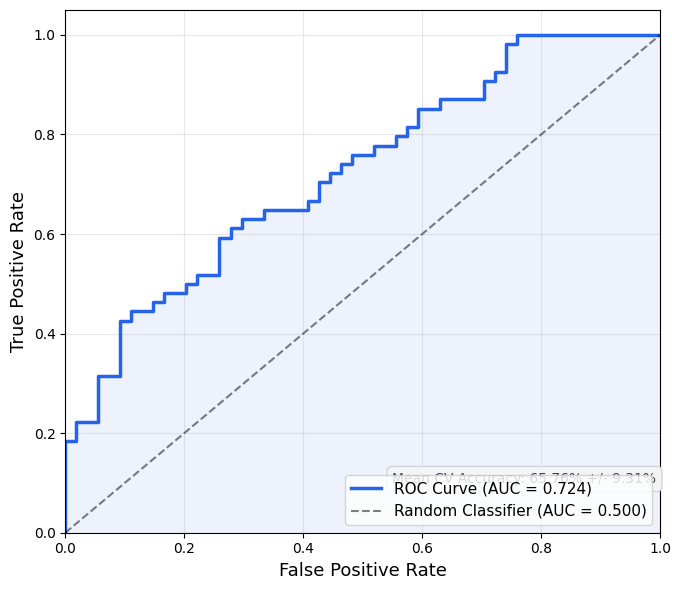

Saved to roc_auc_curve.png


In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2563EB', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2563EB')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.legend(loc='lower right', fontsize=11) 
ax.grid(True, alpha=0.3)
mean_acc = np.mean(fold_results['accuracies']) * 100
std_acc  = np.std(fold_results['accuracies'])  * 100
ax.text(0.55, 0.10, f'Mean CV Accuracy: {mean_acc:.2f}% +/- {std_acc:.2f}%',
        fontsize=10, color='#374151',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F3F4F6', edgecolor='#D1D5DB'))
plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to roc_auc_curve.png')

In [25]:
# 1. MODALITY CONFUSION MATRICES [[TN, FP], [FN, TP]]
# Normalized so that TN+FP=100, FN+TP=100
import numpy as np
from sklearn.metrics import confusion_matrix

# Speech modality: results from 5-fold cross-validation above
cm_speech = confusion_matrix(fold_results['true_labels'], fold_results['predictions'])

def normalize_cm(cm):
    """Normalize confusion matrix so each ROW sums to 100 (TN+FP=100, FN+TP=100)."""
    cm_norm = cm.astype(float)
    for i in range(cm.shape[0]):
        row_sum = cm[i].sum()
        cm_norm[i] = cm[i] / row_sum * 100
    return cm_norm

cm_speech_norm = normalize_cm(cm_speech)

TN, FP = cm_speech[0]
FN, TP = cm_speech[1]
TN_n, FP_n = cm_speech_norm[0]
FN_n, TP_n = cm_speech_norm[1]

print('=' * 55)
print('  MODALITY CONFUSION MATRICES  [[TN, FP], [FN, TP]]')
print('  Normalized: TN+FP=100, FN+TP=100')
print('=' * 55)
print()
print('-- Speech (5-Fold CV) --')
print(f'  Raw:        [[TN={TN:3d}, FP={FP:3d}], [FN={FN:3d}, TP={TP:3d}]]')
print(f'  Normalized: [[TN={TN_n:5.1f}, FP={FP_n:5.1f}], [FN={FN_n:5.1f}, TP={TP_n:5.1f}]]')
print(f'  (TN+FP={TN_n+FP_n:.1f}, FN+TP={FN_n+TP_n:.1f})')
print()
print(f'  Specificity (TN rate): {TN_n:.1f}%')
print(f'  Sensitivity (TP rate): {TP_n:.1f}%')


  MODALITY CONFUSION MATRICES  [[TN, FP], [FN, TP]]
  Normalized: TN+FP=100, FN+TP=100

-- Speech (5-Fold CV) --
  Raw:        [[TN= 39, FP= 15], [FN= 22, TP= 32]]
  Normalized: [[TN= 72.2, FP= 27.8], [FN= 40.7, TP= 59.3]]
  (TN+FP=100.0, FN+TP=100.0)

  Specificity (TN rate): 72.2%
  Sensitivity (TP rate): 59.3%
